## **Redes Perceptron**

Dado um conjunto de observações

$$
\mathcal{D} = \{(\mathbf{x}_n, t_n)\}_{n=1}^N
\quad \mathbf{x}_n \in \mathbb{R}^{D} \quad t_n \in \{-1, +1\}
$$

definimos o **vetor de entrada aumentado** $\phi_n$ (com o viés absorvido como primeira componente):

$$
\phi_n \;=\; \phi(\mathbf{x}_n) \;=\;
\begin{bmatrix} 1 \\ \mathbf{x}_n \end{bmatrix}
$$

O vetor de pesos $\mathbf{w}$ é definido de forma compatível:

$$
\mathbf{w} =
\begin{bmatrix}
w_0 \\ w_1 \\ \vdots \\ w_D
\end{bmatrix}
$$

onde $w_0$ desempenha o papel do viés (*bias*).

Um neurônio artificial recebe $\phi_n$ e computa uma saída por meio de duas operações em sequência.

**Combinação linear (pré-ativação):**

$$
a_n = \mathbf{w}^{\top}\phi_n = \sum_{j=0}^{D} w_j\,\phi_j(\mathbf{x}_n)
$$

**Aplicação da função de ativação:**

$$
y_n = f(a_n)
$$

onde, no perceptron, $f(\cdot)$ é a função degrau de Heaviside na forma bipolar:

$$
f(a) = \begin{cases}
+1, & a \geq 0, \\
-1, & a < 0.
\end{cases}
$$

### **Critério de Erro e Regra de Atualização**

Caso a escolha da função de perda seja contar o número de exemplos mal classificados, métodos de gradiente se tornam inviáveis

Assim, Rosenblatt (1962) propôs o **critério do perceptron**, que penaliza a ativação dos exemplos mal classificados:

$$
\mathcal{L}_P(\mathbf{w}) = -\sum_{n \in \mathcal{M}} \mathbf{w}^{\top}\phi_n\, t_n
$$

onde $\mathcal{M} \subseteq \{1, \ldots, N\}$ denota o conjunto de índices dos exemplos **mal classificados**, isto é, aqueles para os quais $\mathbf{w}^{\top}\phi_n\, t_n < 0$.


O valor de $\mathbf{w}^{\top}\phi_n\, t_n$ é negativo quando o modelo atribui sinal errado a $\phi_n$, de modo que $\mathcal{L}_P \geq 0$ e a minimização busca reduzir essa penalidade.

Calculando o gradiente de $\mathcal{L}_P$ em relação a $\mathbf{w}$:

$$
\nabla_{\mathbf{w}}\,\mathcal{L}_P = -\sum_{n \in \mathcal{M}} \phi_n\, t_n
$$

Aplicando um passo de gradiente descendente estocástico em um único exemplo mal classificado $n \in \mathcal{M}$, obtemos:

$$
\mathbf{w}^{(\tau+1)} = \mathbf{w}^{(\tau)} + \eta\,\phi_n\, t_n
$$

onde $\eta > 0$ é a taxa de aprendizado e $\tau$ indexa as iterações do algoritmo.

> BISHOP, Christopher M. Pattern Recognition and Machine Learning. New York: Springer, 2006. Seção 4.1.7, p. 192.


> FACELI, Katti; LORENA, Ana Carolina; GAMA, João; CARVALHO, André C. P. L. F. de. Inteligência Artificial: Uma Abordagem de Aprendizado de Máquina. Rio de Janeiro: LTC, 2011. Seção 7.1, p. 109.


## **Aplicação de Rede Perceptron**

Vamos utilizar uma **Rede Perceptron** para **classificação** em um dataset sintético.



### **Pré-processamento dos dados**

#### **Dataset**

In [1]:
from sklearn.datasets import make_blobs
import numpy as np

X, t = make_blobs(
    n_samples=200,
    centers=2,
    cluster_std=2.2,
    random_state=42
)

t = np.where(t == 0, -1, 1)

class_names = ["Class A", "Class B"]

#### **Visualização dos dados**

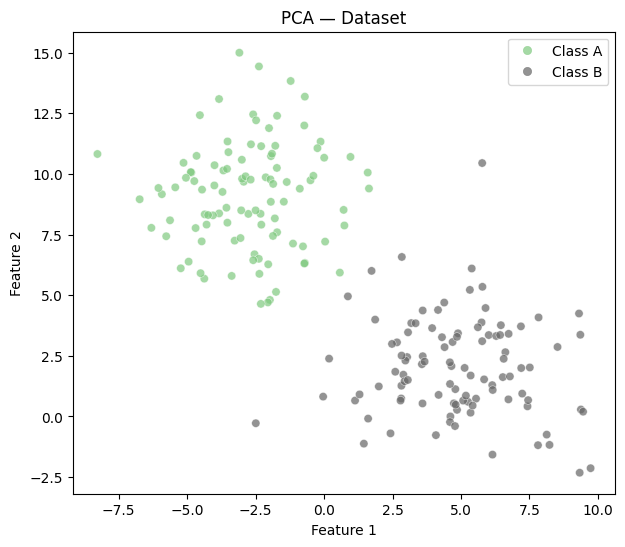

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 6))

scatter = ax.scatter(X[:, 0], X[:, 1], c=t,
                     cmap="Accent", edgecolors="white", linewidths=0.4, alpha=0.7)

handles, _ = scatter.legend_elements()
ax.legend(handles, class_names)
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_title("PCA — Dataset")

plt.show()

#### **Divisão do dataset em conjuntos de treino e validação**

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, t_train, t_test = train_test_split(
    X, t,
    test_size=0.2,
    random_state=42
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (160, 2)
Teste: (40, 2)


#### **Padronização dos dados (z-score)**

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#### **Construção do vetor $\phi(\mathbf{x}_n)$**

In [5]:
def add_bias(X):
    ones = np.ones((X.shape[0], 1))
    return np.hstack((ones, X))

X_train = add_bias(X_train)
X_test = add_bias(X_test)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (160, 3)
Teste: (40, 3)


### **Implementação da Rede Perceptron**

#### **Funções Auxiliares**

In [6]:
def f_degrau(a):
    return 1 if a >= 0 else -1

def loss_rosenblatt(phi, t, w):
    misclassified = [i for i in range(len(t)) if w @ phi[i] * t[i] < 0]
    return -sum(w @ phi[i] * t[i] for i in misclassified)

def train_perceptron(X_train, t_train, max_iter=1000, eta=1.0, seed=42):
    n, d = X_train.shape
    rng = np.random.default_rng(seed)
    w = rng.normal(0, 0.01, d)
    losses = []

    for epoch in range(max_iter):
        misclassified = False

        for i in range(n):
            if w @ X_train[i] * t_train[i] < 0:
                w = w + eta * X_train[i] * t_train[i]
                misclassified = True

        loss = loss_rosenblatt(X_train, t_train, w)
        losses.append(loss)

        if not misclassified:
            break

    return w, losses

### **Treinamento e Validação**

#### **Treinamento**

In [7]:
w, losses = train_perceptron(X_train, t_train)

#### **Valor de $\mathbf{w}$ ótimo**

In [8]:
for i, b in enumerate(w.flatten()):
    print(f"w{i}: {b:.4f}")

w0: 1.0030
w1: 4.0876
w2: -2.5680


#### **Curva de Aprendizado**

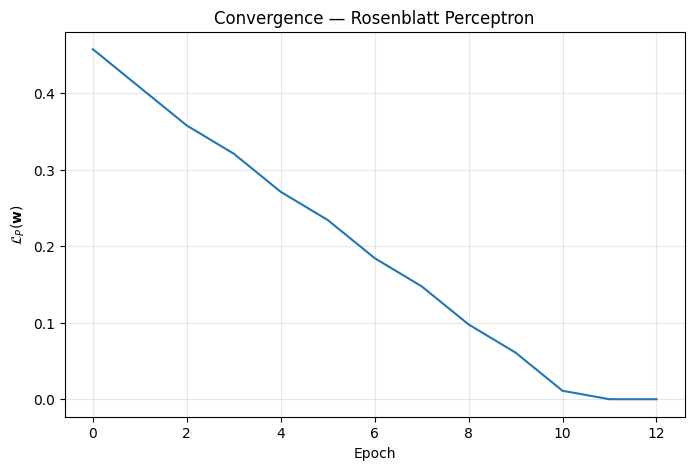

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel(r"$\mathcal{L}_P(\mathbf{w})$")
plt.title("Convergence — Rosenblatt Perceptron")
plt.grid(True, alpha=0.3)

plt.show()

#### **Validação**

In [10]:
def predict(X_test, t_test, w):
    y_pred = [f_degrau(w.T @ X_test[i]) for i in range(len(t_test))]
    return y_pred

In [11]:
y_pred = predict(X_test, t_test, w)

#### **Matriz de Confusão**

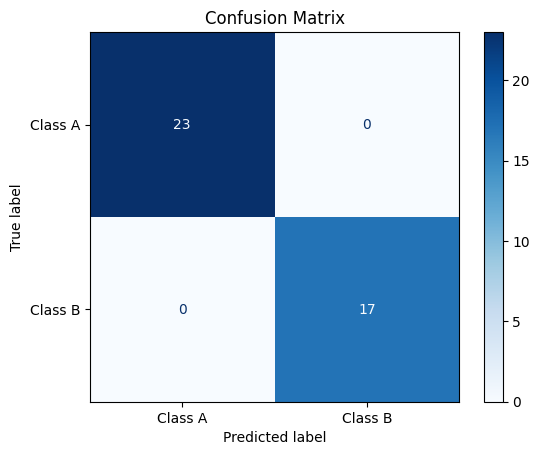

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(t_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

#### **Métricas**

In [13]:
from sklearn.metrics import classification_report

print(classification_report(t_test, y_pred, target_names=class_names))

              precision    recall  f1-score   support

     Class A       1.00      1.00      1.00        23
     Class B       1.00      1.00      1.00        17

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



### **Fronteira de Decisão**

Com o Perceptron, a fronteira de decisão é a reta onde $\mathbf{w}^{\top}\,\phi = 0$.

Dado que para o nosso problema:

$$
\mathbf{w} =
\begin{bmatrix}
w_0 \\ w_1 \\ w_2
\end{bmatrix}
\quad
\text{e}
\quad
\phi = \begin{bmatrix}
1 \\ x_1 \\ x_2 \\
\end{bmatrix}
$$

a equação da fronteira de decisão é dada por:

$$
w_0 + x_1w_1 + x_2w_2 = 0 \Rightarrow x_2 = \dfrac{- w_0 - x_1w_1}{w_2}
$$

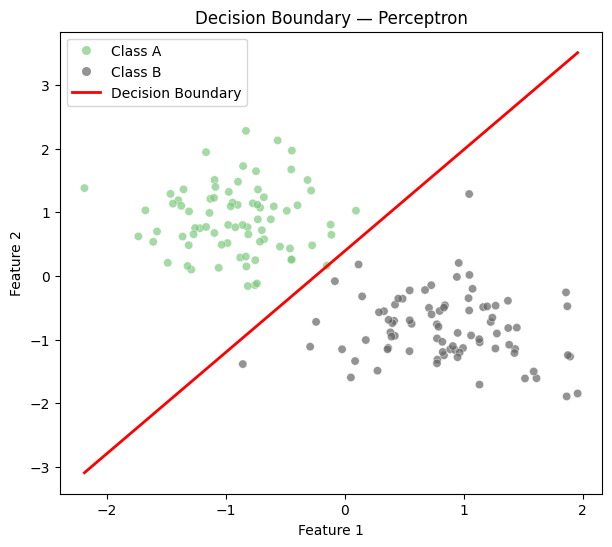

In [14]:
x1 = np.linspace(X_train[:, 1].min(), X_train[:, 1].max(), 100)

x2 = (-w[0] - w[1] * x1) / w[2]

fig, ax = plt.subplots(figsize=(7, 6))

scatter = ax.scatter(X_train[:, 1], X_train[:, 2], c=t_train,
                     cmap="Accent", edgecolors="white", linewidths=0.4, alpha=0.7)

ax.plot(x1, x2, color="red", linewidth=2)

handles, _ = scatter.legend_elements()
handles.append(plt.Line2D([0], [0], color="red", linewidth=2))
ax.legend(handles, class_names + ["Decision Boundary"])

ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_title("Decision Boundary — Perceptron")
plt.show()